# Crypto Price Analysis

This notebook analyzes the price data collected by `ingest.py` into `crypto_prices.db`. It answers three analyst-style questions:

1. **Which coin is most volatile** in this session, and what does that mean for risk?
2. **How correlated** are these coins' price movements with each other?
3. **What anomalies** (large pull-over-pull moves) happened, and when?

> Run `ingest.py` locally for a while first (an hour or more is ideal) so there's enough data here to be meaningful. This notebook reads from the local `crypto_prices.db` file — it won't work against the deployed Streamlit Cloud version, since that version fetches live data directly and doesn't persist a database.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "crypto_prices.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM prices ORDER BY id ASC", conn)
conn.close()

df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Loaded {len(df)} rows covering {df['coin'].nunique()} coins")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Loaded 160 rows covering 4 coins
Time range: 2026-09-23 16:38:42.684331+00:00 to 2026-09-24 06:30:31.061443+00:00


,id,coin,price_usd,pct_change_24h,timestamp
0,1,bitcoin,84186.000000,-2.298647,2026-09-23 16:38:42.684331+00:00
1,2,ethereum,2664.660000,-2.567591,2026-09-23 16:38:42.720783+00:00
2,3,solana,114.530000,-2.142683,2026-09-23 16:38:42.731698+00:00
3,4,dogecoin,0.092552,-6.328849,2026-09-23 16:38:42.740580+00:00
4,5,bitcoin,84033.000000,-2.525147,2026-09-23 16:43:44.746131+00:00


In [2]:
ts = df["timestamp"].sort_values().drop_duplicates()
gaps = ts[ts.diff() > pd.Timedelta("30min")]
if len(gaps):
    df = df[df["timestamp"] >= gaps.iloc[-1]].copy()
print(len(df), "rows,", df["timestamp"].min(), "to", df["timestamp"].max())

108 rows, 2026-09-24 05:02:23.581006+00:00 to 2026-09-24 06:30:31.061443+00:00


## 1. Volatility comparison

We measure volatility as the standard deviation of pull-over-pull % price changes for each coin. A higher number means the price swings around more between each 5-minute pull -- i.e. it's riskier / less stable over this session.

In [3]:
df = df.sort_values(["coin", "timestamp"])
df["pct_change"] = df.groupby("coin")["price_usd"].pct_change() * 100

volatility = (
    df.groupby("coin")["pct_change"]
    .std()
    .sort_values(ascending=False)
    .rename("volatility_pct_std")
)
volatility

coin
dogecoin    0.192203
ethereum    0.108788
solana      0.107057
bitcoin     0.078437
Name: volatility_pct_std, dtype: float64

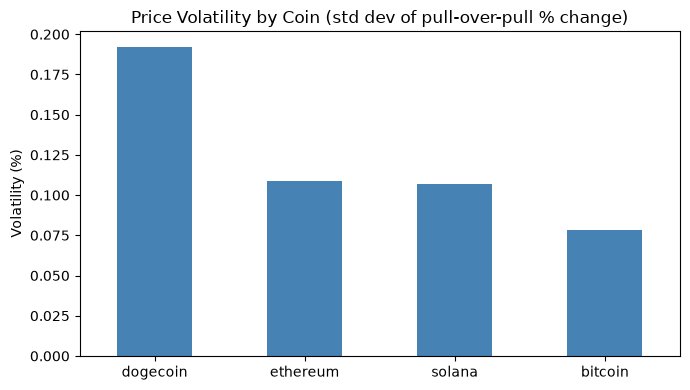

In [4]:
volatility.plot(kind="bar", figsize=(7, 4), color="steelblue")
plt.title("Price Volatility by Coin (std dev of pull-over-pull % change)")
plt.ylabel("Volatility (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("CRYPTO_DASHBOARD_RESULT/volatility_comparison.png", dpi=150)
plt.show()

**Takeaway:** Dogecoin was the most volatile coin in this session (~0.19% std dev of pull-over-pull moves), about 2.5x more volatile than bitcoin (~0.08%). This matches the general pattern in crypto markets: bitcoin, the most established and liquid asset, tends to move more steadily, while lower-cap, meme-driven coins like dogecoin see sharper short-term swings. Ethereum (~0.11%) and solana (~0.11%) sit in between, closer to bitcoin than to dogecoin.

## 2. Correlation between coins

Do these coins move together, or independently? We pivot the data so each coin is a column of prices over time, then compute the correlation matrix of their price changes. A correlation close to 1 means two coins tend to rise and fall together; close to 0 means they move independently.

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["ts_bucket"] = df["timestamp"].dt.floor("5min")

pivot = df.pivot_table(index="ts_bucket", columns="coin",
                       values="price_usd", aggfunc="last").sort_index()
returns = pivot.pct_change().dropna()
corr = returns.corr()
print(pivot.shape)
corr

(19, 4)


coin,bitcoin,dogecoin,ethereum,solana
coin,,,,
bitcoin,1.000000,0.900021,0.947763,0.928034
dogecoin,0.900021,1.000000,0.919956,0.853676
ethereum,0.947763,0.919956,1.000000,0.947109
solana,0.928034,0.853676,0.947109,1.000000


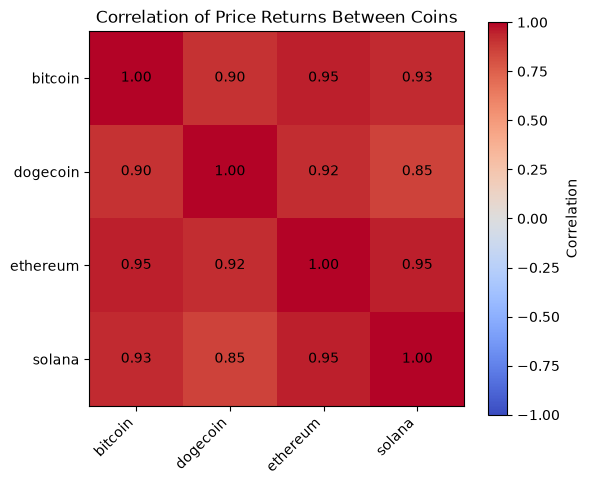

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Correlation of Price Returns Between Coins")
plt.colorbar(im, label="Correlation")
plt.tight_layout()
plt.savefig("CRYPTO_DASHBOARD_RESULT/correlation_heatmap.png", dpi=150)
plt.show()

**Takeaway:** All four coins moved closely together (correlations between 0.85 and 0.95). Bitcoin and ethereum were the most correlated pair (0.95), and dogecoin and solana the least (0.85), though still high. Holding these coins together therefore gives little diversification, since they respond to the same market-wide moves. This is based on only about 18 five-minute returns, so treat it as indicative.

## 3. Anomaly review

Pull-over-pull moves of 3% or more, flagged the same way `ingest.py` flags them live. This turns the raw anomaly alerts into a reviewable table: when they happened, which coin, and how large the move was.

In [7]:
ANOMALY_THRESHOLD_PCT = 3.0

anomalies = df[df["pct_change"].abs() >= ANOMALY_THRESHOLD_PCT].copy()
anomalies = anomalies[["coin", "timestamp", "price_usd", "pct_change"]].sort_values("timestamp")
print(f"{len(anomalies)} anomalies detected out of {len(df)} total price pulls "
      f"({len(anomalies) / len(df) * 100:.1f}%)")
anomalies

0 anomalies detected out of 108 total price pulls (0.0%)


,coin,timestamp,price_usd,pct_change


In [8]:
df.loc[df["pct_change"].abs().nlargest(5).index,
       ["coin", "timestamp", "price_usd", "pct_change"]]

,coin,timestamp,price_usd,pct_change
59,dogecoin,2026-09-24 05:07:25.337398+00:00,0.094834,0.776808
57,ethereum,2026-09-24 05:07:25.322338+00:00,2691.000000,0.378986
58,solana,2026-09-24 05:07:25.330214+00:00,115.670000,0.268724
56,bitcoin,2026-09-24 05:07:25.310048+00:00,84220.000000,0.259518
67,dogecoin,2026-09-24 05:17:29.018894+00:00,0.094725,-0.229611


**Takeaway:** No price pull crossed the 3% anomaly threshold (0 of 108 pulls). The largest move was dogecoin at +0.78%. The top four moves all came from the same pull (05:07 UTC on Sep 24) and were all upward, which looks like one small market-wide move. A 3% threshold may be too high for a 5-minute window, and a lower one (for example 0.5%) would be worth testing once more data is collected.

In [9]:
df["gap_min"] = df.groupby("coin")["timestamp"].diff().dt.total_seconds() / 60
df["gap_min"].describe()

count    104.000000
mean       3.389385
std        1.201606
min        2.487685
25%        2.501472
50%        2.536597
75%        5.030065
max        5.040097
Name: gap_min, dtype: float64

## Summary

Fill this in once you've run the notebook against real collected data -- this is what you'd walk an interviewer through:

- **Most volatile coin:** dogecoin (~0.19% std dev per pull)
- **Least volatile coin:** _bitcoin (~0.08%)__
- **Most correlated pair:**_bitcoin and ethereum (0.95)
- **Number of anomalies detected:** _0 of 108 pulls at the 3% threshold__
- **What this would inform in a real business setting:** ea risk desk could use the volatility ranking to size positions, and the correlation matrix to check whether a portfolio is actually diversified or secretly concentrated in one market factor.
- **What I'd add with more data:**  rolling volatility over multiple days, comparing against a longer historical baseline instead of just this session, and backtesting whether the 3% anomaly threshold actually catches meaningful moves without too many false positives.
- **Limitation:** about 1.5 hours of continuous data (an overnight collection gap was removed), so results are indicative rather than conclusive.